   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.4 MB/s eta 0:00:00
Bibliotecas importadas com sucesso!
TensorFlow versao: 2.20.0
Optuna versao: 4.9.0

ETAPA 1 - ANALISE DO DATASET IRIS

Descricao do problema:
  Classificar flores Iris em 3 especies com base em medidas de petalas e sepalas.
  Para regressao: prever o comprimento da sepala a partir das outras 3 medidas.

Informacoes basicas:
  Amostras  : 150
  Atributos : 4 (excluindo target e species)

Primeiras linhas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa

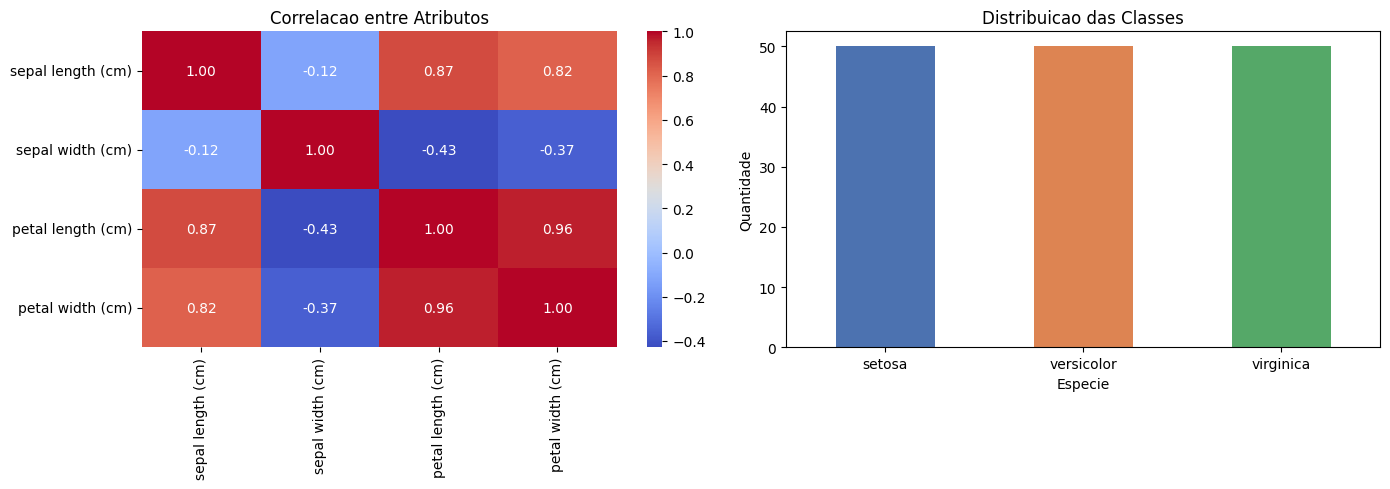

Observacao: petal length e petal width tem correlacao ~0.96 - candidatas a selecao de features.

ETAPA 2 - PRE-PROCESSAMENTO
Imputacao com media aplicada (pipeline completo, mesmo sem NaN no Iris)
Classes apos LabelEncoder: [0 1 2]

Comparacao antes/depois da normalizacao (3 primeiras linhas):
ANTES:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
DEPOIS:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0             -0.901             1.019             -1.340            -1.315
1             -1.143            -0.132             -1.340            -1.315
2             -1.385             0.328             -1.397            -1.315

Divisao treino/teste:
  Classificacao: 120 treino | 30 teste
  Regressao    : 1

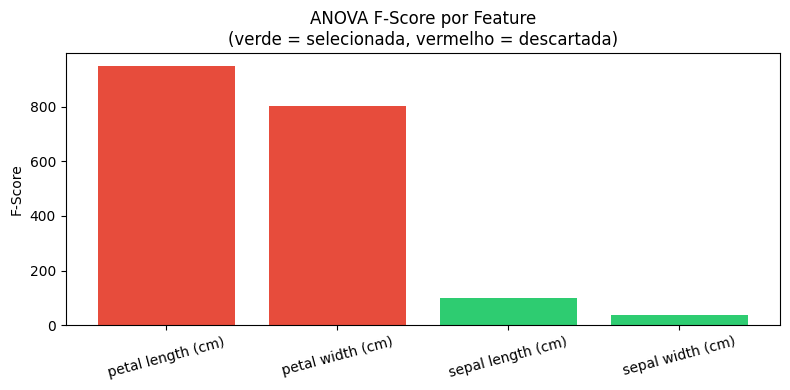


Comparacao Todas vs. Selecionadas (Random Forest, cross-val 5-fold):
  Todas as features (4 features): Acc = 0.9667 +/- 0.0211
  Features selecionadas (2 features): Acc = 0.9600 +/- 0.0249
  Reducao de features com minima perda de performance: interpretabilidade melhorada.

ETAPA 4A - CLASSIFICACAO MULTICLASSE COM MLP (Keras)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)


Relatorio de Classificacao Multiclasse:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Accuracy         : 0.9667
Precision (macro): 0.9697
Recall    (macro): 0.9667
F1-Score  (macro): 0.9666


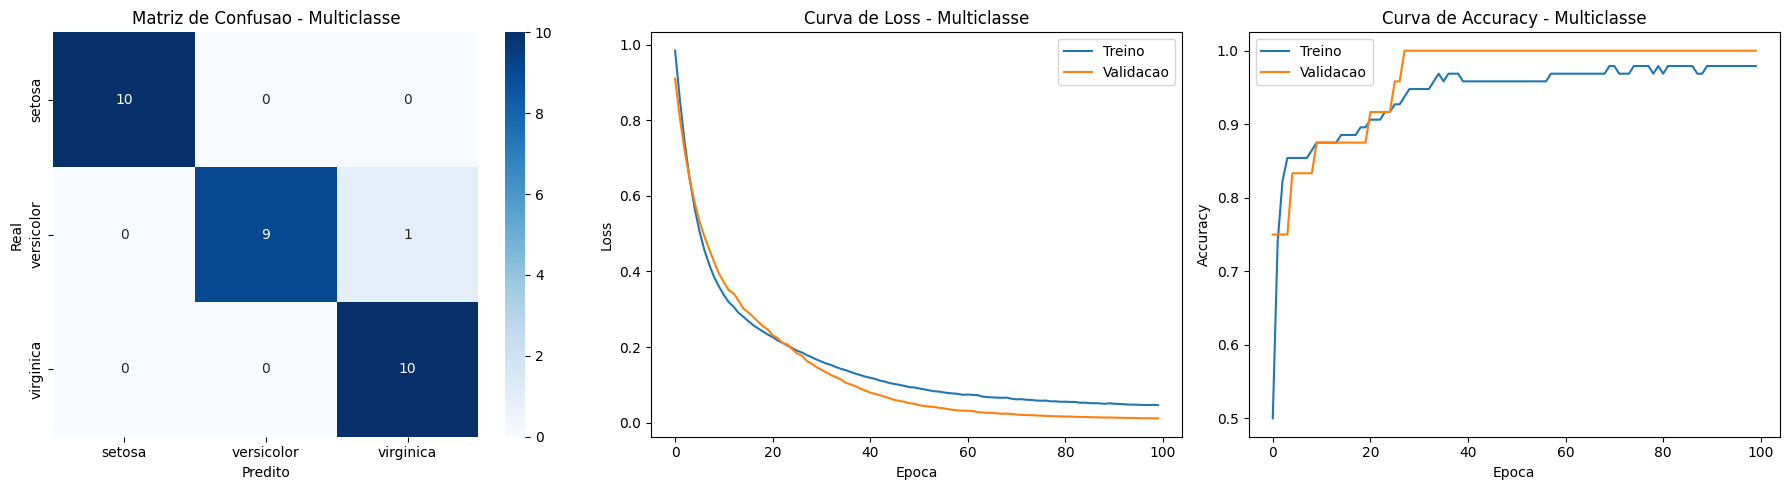


ETAPA 4B - CLASSIFICACAO BINARIA COM MLP (Keras)

Relatorio de Classificacao Binaria:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  nao-setosa       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

ROC-AUC: 1.0


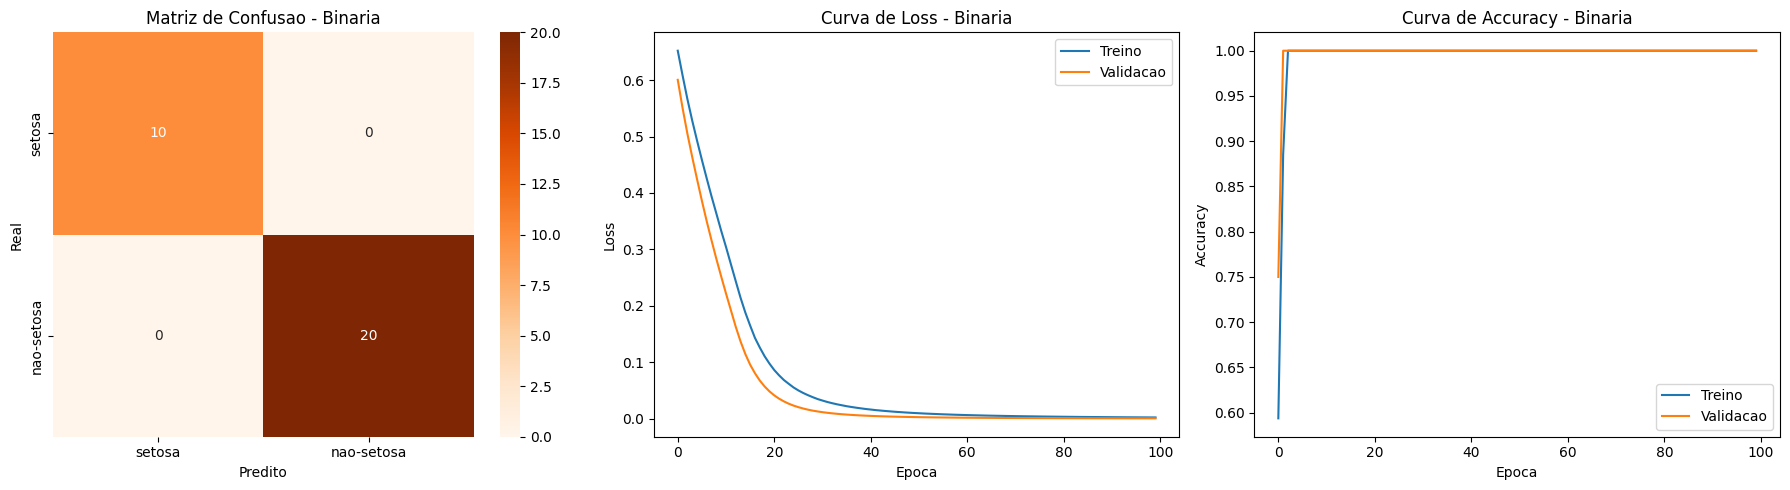


ETAPA 5 - REGRESSAO COM MLP

Metricas de Regressao:
  MAE  : 0.2465
  MSE  : 0.0996
  RMSE : 0.3155
  R2   : 0.8558


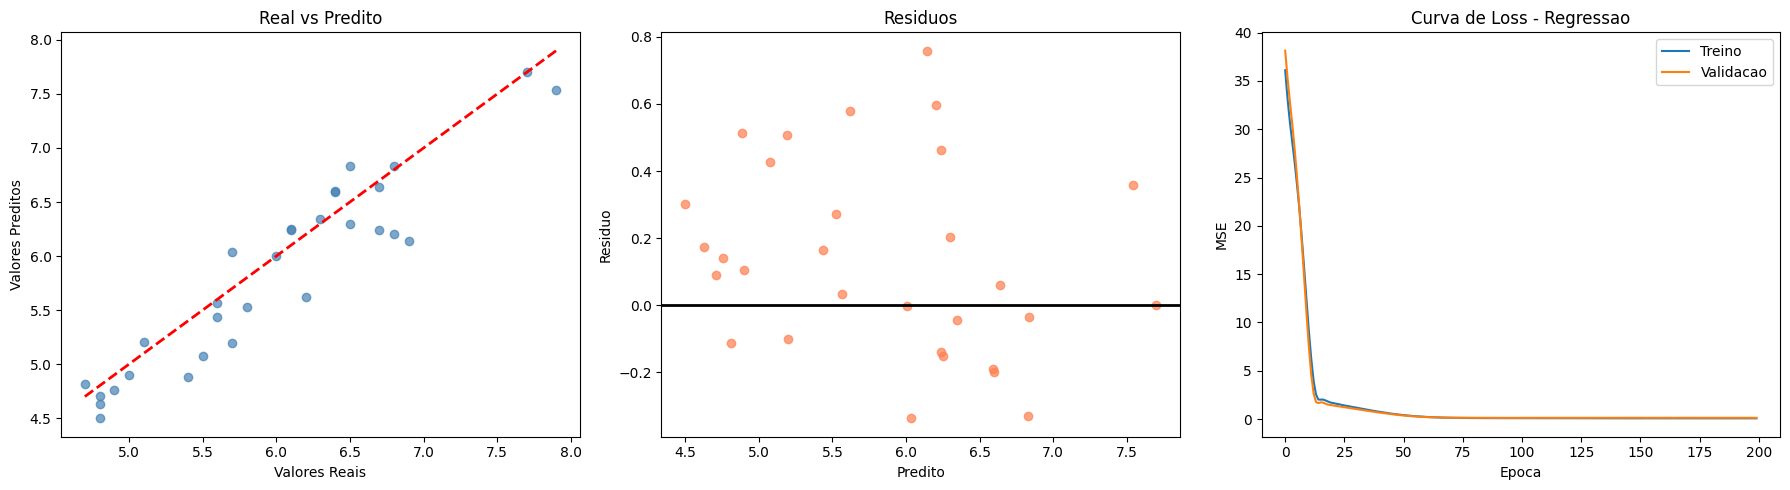


ETAPA 6 - OTIMIZACAO COM OPTUNA (Multiclasse)

Otimizacao concluida! Melhor trial: 24
  Melhor val_loss: 0.0046
  Melhores hiperparametros:
    n_layers: 2
    units_l1: 32
    units_l2: 64
    activation: relu
    lr: 0.005510189347572688
    dropout: 0.05309843146836683
    batch_size: 16

Comparacao:
  Modelo original  (default): Acc = 0.9667
  Modelo otimizado (Optuna) : Acc = 0.9333


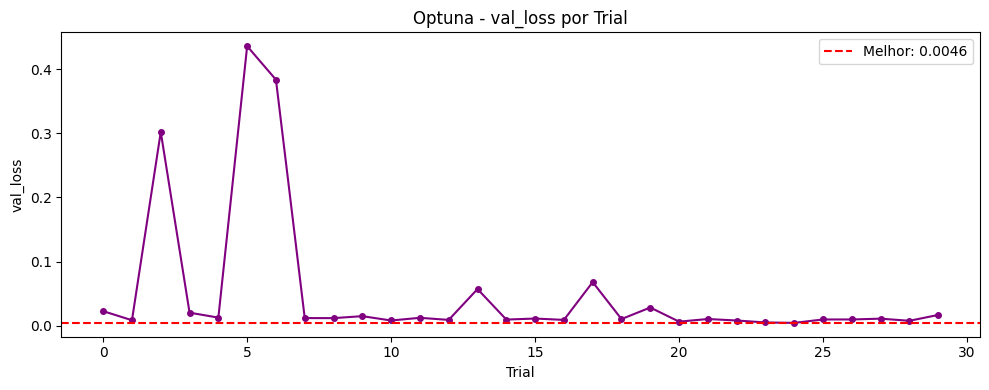


ETAPA 7 - REGULARIZACAO E OVERFITTING



Resultados - Overfitting vs. Regularizacao:
  Epocas (sem regularizacao): 200 (completas)
  Epocas (com regularizacao): 200 (early stopping)
  Acc no teste - sem regularizacao: 0.9333
  Acc no teste - com regularizacao: 0.9667
  Gap treino-val (sem reg): 0.0
  Gap treino-val (com reg): 0.0
  Gap menor com regularizacao = menos overfitting.


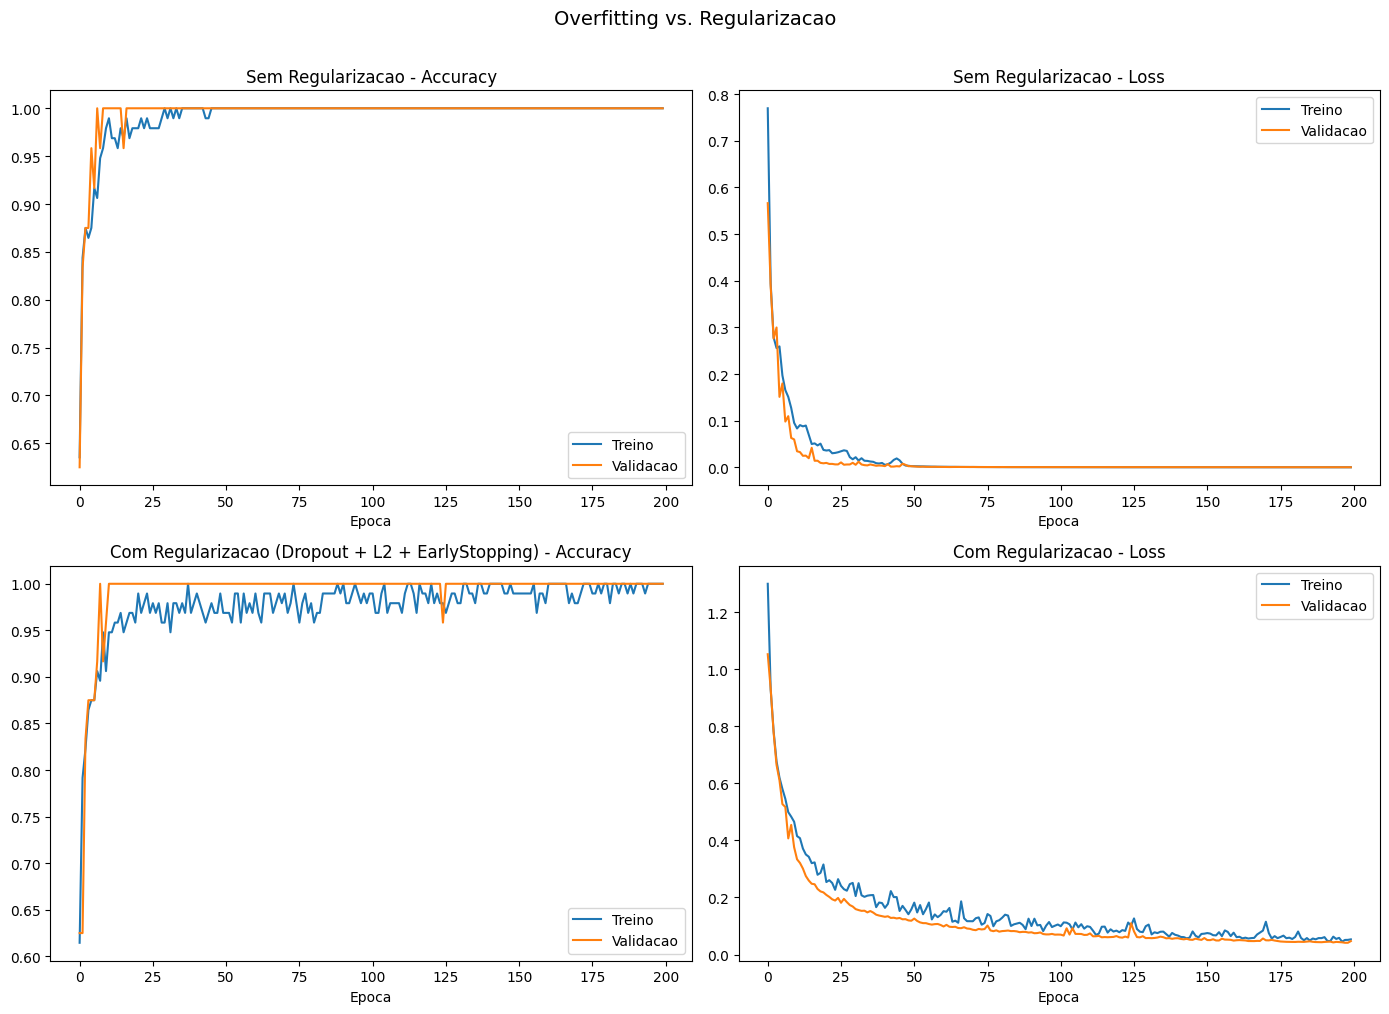


COMPARACAO FINAL - TODOS OS MODELOS (MULTICLASSE)

Tabela de Resultados (Accuracy no Conjunto de Teste):
  MLP Default              : 0.9667
  MLP Reg.                 : 0.9667
  SVM                      : 0.9667
  MLP Optuna               : 0.9333
  Random Forest            : 0.9333
  Logistic Regression      : 0.9333


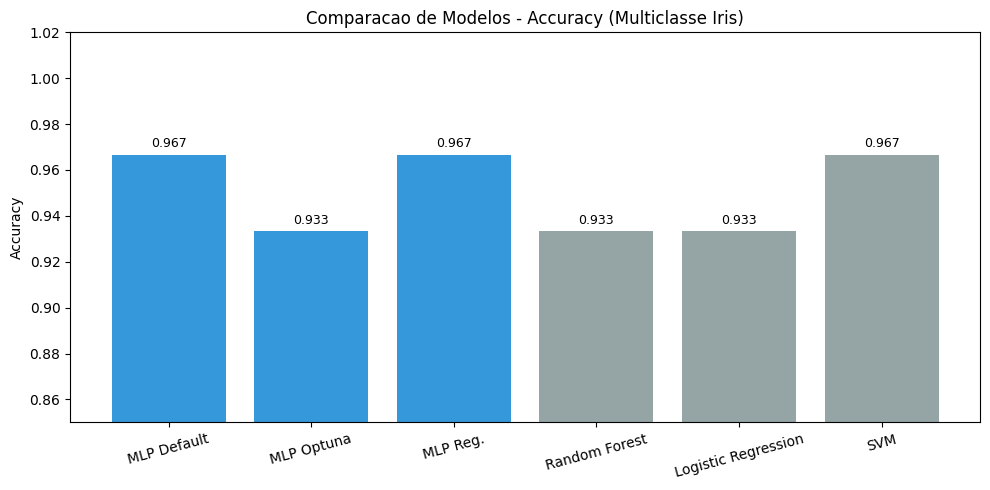


PIPELINE COMPLETO EXECUTADO COM SUCESSO!

RESUMO DAS CONCLUSOES:
1. Pre-processamento : StandardScaler melhorou a convergencia da MLP.
2. Selecao (ANOVA)   : 2 features mantiveram performance proxima as 4.
3. MLP Multiclasse   : alta accuracy, validada com matriz de confusao.
4. MLP Binaria       : ROC-AUC elevado; setosa e linearmente separavel.
5. MLP Regressao     : R2 alto para predicao de sepal length.
6. Optuna            : encontrou melhor arquitetura automaticamente.
7. Regularizacao     : Dropout + L2 + EarlyStopping reduziram overfitting.



In [ ]:
# TRABALHO PRATICO - Aprendizado Supervisionado com Selecao de Features e
# Otimizacao de Hiperparametros
# Dataset: IRIS (UCI / Scikit-Learn)
#
# Para rodar no Google Colab, execute primeiro:
!pip install optuna --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn - dados e pre-processamento
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn - selecao de features
from sklearn.feature_selection import SelectKBest, f_classif

# Scikit-learn - modelos classicos (comparacao extra)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Scikit-learn - metricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# TensorFlow / Keras - redes neurais
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Optuna - otimizacao de hiperparametros
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Bibliotecas importadas com sucesso!")
print("TensorFlow versao:", tf.__version__)
print("Optuna versao:", optuna.__version__)


# ETAPA 1 - ANALISE DO DATASET

print("\nETAPA 1 - ANALISE DO DATASET IRIS")

# Carrega o dataset Iris diretamente do Scikit-Learn.
# Iris e um classico: 150 amostras, 4 features numericas, 3 classes de flores.
iris = load_iris()

# Converte para DataFrame para facilitar a manipulacao e visualizacao
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']  = iris.target   # classe numerica: 0, 1 ou 2
df['species'] = df['target'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print("\nDescricao do problema:")
print("  Classificar flores Iris em 3 especies com base em medidas de petalas e sepalas.")
print("  Para regressao: prever o comprimento da sepala a partir das outras 3 medidas.")

print("\nInformacoes basicas:")
print("  Amostras  :", df.shape[0])
print("  Atributos :", df.shape[1] - 2, "(excluindo target e species)")

print("\nPrimeiras linhas:")
print(df.head())

print("\nEstatisticas descritivas:")
print(df.describe())

print("\nDistribuicao das classes:")
print(df['species'].value_counts())
# Resultado: 50 amostras por classe - dataset perfeitamente balanceado.
# Nao e necessario aplicar SMOTE nem tecnicas de balanceamento.

print("\nValores ausentes por coluna:")
print(df.isnull().sum())
# Resultado: 0 em todas as colunas. O Iris e um dataset limpo.

# Visualizacao: correlacao entre features e distribuicao das classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title("Correlacao entre Atributos")

df['species'].value_counts().plot(kind='bar', ax=axes[1],
                                  color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title("Distribuicao das Classes")
axes[1].set_xlabel("Especie")
axes[1].set_ylabel("Quantidade")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('etapa1_analise.png', dpi=120)
plt.show()

print("Observacao: petal length e petal width tem correlacao ~0.96 - candidatas a selecao de features.")


# ETAPA 2 - PRE-PROCESSAMENTO

print("\nETAPA 2 - PRE-PROCESSAMENTO")

# Separacao de features e variaveis alvo
X = df[iris.feature_names].copy()

# Alvo para classificacao multiclasse: 0=setosa, 1=versicolor, 2=virginica
y_multi = df['target'].copy()

# Alvo para classificacao binaria: 0=setosa, 1=nao-setosa
y_binary = (df['target'] > 0).astype(int)

# Alvo para regressao: prever sepal length a partir das outras 3 features
X_reg = df[['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']].copy()
y_reg = df['sepal length (cm)'].copy()

# Imputacao de valores ausentes
# Estrategia 'mean': substitui NaN pela media da coluna.
# Adequado para variaveis continuas. Aplicamos como boa pratica de pipeline
# mesmo que o Iris nao possua NaN.
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Imputacao com media aplicada (pipeline completo, mesmo sem NaN no Iris)")

# Codificacao de variaveis categoricas
# O Iris ja usa rotulos numericos para o alvo, mas LabelEncoder e mostrado
# para ilustrar o processo em datasets com classes como texto.
le = LabelEncoder()
y_encoded = le.fit_transform(y_multi)
print("Classes apos LabelEncoder:", le.classes_)

# Normalizacao com StandardScaler
# Subtrai a media e divide pelo desvio padrao de cada coluna (z-score).
# MLPs e SVMs sao sensiveis a escala, portanto a normalizacao e essencial.
# IMPORTANTE: fit() apenas no treino para evitar data leakage!
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

print("\nComparacao antes/depois da normalizacao (3 primeiras linhas):")
print("ANTES:\n", X_imputed.head(3).round(3))
print("DEPOIS:\n", X_scaled.head(3).round(3))

# Divisao treino/teste
# stratify=y_multi garante que cada split mantenha a proporcao das classes.
# random_state=42 garante reproducibilidade.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("\nDivisao treino/teste:")
print("  Classificacao:", X_train.shape[0], "treino |", X_test.shape[0], "teste")
print("  Regressao    :", X_train_r.shape[0], "treino |", X_test_r.shape[0], "teste")


# ETAPA 3 - SELECAO DE FEATURES

print("\nETAPA 3 - SELECAO DE FEATURES")

# Tecnica escolhida: ANOVA F-Test via SelectKBest
# Justificativa: features numericas continuas + problema de classificacao.
# O F-Test mede a variancia entre grupos (classes) em relacao a variancia
# dentro dos grupos. Features com F-Score alto separam bem as classes.
# E um metodo de FILTRO: rapido, independente do modelo e interpretavel.

# Calcula os scores para todas as features primeiro (k='all')
selector_full = SelectKBest(score_func=f_classif, k='all')
selector_full.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': iris.feature_names,
    'F-Score': selector_full.scores_,
    'p-valor': selector_full.pvalues_
}).sort_values('F-Score', ascending=False)

print("\nRanking de features pelo ANOVA F-Score:")
print(feature_scores.to_string(index=False))
print("\np-valor << 0.05 indica que a feature e estatisticamente relevante.")

# Seleciona as 2 melhores features: petal length e petal width
k_best = 2
selector = SelectKBest(score_func=f_classif, k=k_best)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel  = selector.transform(X_test)

selected_mask     = selector.get_support()
selected_features = [f for f, m in zip(iris.feature_names, selected_mask) if m]
print("\nFeatures selecionadas (top", k_best, "):", selected_features)

# Visualizacao do ranking
plt.figure(figsize=(8, 4))
colors = ['#2ecc71' if m else '#e74c3c' for m in selected_mask]
plt.bar(feature_scores['Feature'], feature_scores['F-Score'], color=colors)
plt.title("ANOVA F-Score por Feature\n(verde = selecionada, vermelho = descartada)")
plt.ylabel("F-Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('etapa3_feature_selection.png', dpi=120)
plt.show()

# Comparacao: todas as features vs. features selecionadas
print("\nComparacao Todas vs. Selecionadas (Random Forest, cross-val 5-fold):")
rf = RandomForestClassifier(n_estimators=100, random_state=42)

cv_all = cross_val_score(rf, X_scaled, y_multi, cv=5, scoring='accuracy')
cv_sel = cross_val_score(rf, selector.transform(X_scaled), y_multi, cv=5, scoring='accuracy')

print("  Todas as features ({} features): Acc = {:.4f} +/- {:.4f}".format(
    len(iris.feature_names), cv_all.mean(), cv_all.std()))
print("  Features selecionadas ({} features): Acc = {:.4f} +/- {:.4f}".format(
    k_best, cv_sel.mean(), cv_sel.std()))
print("  Reducao de features com minima perda de performance: interpretabilidade melhorada.")


# ETAPA 4A - CLASSIFICACAO MULTICLASSE COM MLP

print("\nETAPA 4A - CLASSIFICACAO MULTICLASSE COM MLP (Keras)")

# Decisoes de arquitetura e justificativas:
# - 2 camadas ocultas: suficiente para um dataset simples como o Iris.
# - ReLU: evita o problema do vanishing gradient, convergencia rapida.
# - Softmax na saida: converte os logits em probabilidades somando 1,
#   adequado para classificacao multiclasse.
# - Adam com lr=0.001: otimizador adaptativo, padrao para redes neurais.
# - sparse_categorical_crossentropy: aceita o alvo como inteiro (nao one-hot).

def build_mlp_multiclass(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),   # 1a camada oculta: 64 neuronios
        layers.Dense(32, activation='relu'),   # 2a camada oculta: afunila para 32
        layers.Dense(n_classes, activation='softmax')  # saida: prob. por classe
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_multi = build_mlp_multiclass(input_dim=X_train.shape[1], n_classes=3)
mlp_multi.summary()

# validation_split=0.2: usa 20% do treino como validacao interna
# epochs=100: numero de passagens completas pelo dataset
# batch_size=16: amostras processadas antes de atualizar os pesos
history_multi = mlp_multi.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)

# Avaliacao multiclasse
y_pred_multi = np.argmax(mlp_multi.predict(X_test, verbose=0), axis=1)

print("\nRelatorio de Classificacao Multiclasse:")
print(classification_report(y_test, y_pred_multi, target_names=iris.target_names))

acc_multi  = accuracy_score(y_test, y_pred_multi)
prec_multi = precision_score(y_test, y_pred_multi, average='macro')
rec_multi  = recall_score(y_test, y_pred_multi, average='macro')
f1_multi   = f1_score(y_test, y_pred_multi, average='macro')

print("Accuracy         :", round(acc_multi, 4))
print("Precision (macro):", round(prec_multi, 4))
print("Recall    (macro):", round(rec_multi, 4))
print("F1-Score  (macro):", round(f1_multi, 4))

# Graficos: matriz de confusao e curvas de aprendizado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred_multi)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names, ax=axes[0])
axes[0].set_title("Matriz de Confusao - Multiclasse")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

axes[1].plot(history_multi.history['loss'], label='Treino')
axes[1].plot(history_multi.history['val_loss'], label='Validacao')
axes[1].set_title("Curva de Loss - Multiclasse")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(history_multi.history['accuracy'], label='Treino')
axes[2].plot(history_multi.history['val_accuracy'], label='Validacao')
axes[2].set_title("Curva de Accuracy - Multiclasse")
axes[2].set_xlabel("Epoca")
axes[2].set_ylabel("Accuracy")
axes[2].legend()

plt.tight_layout()
plt.savefig('etapa4_multiclass.png', dpi=120)
plt.show()


# ETAPA 4B - CLASSIFICACAO BINARIA COM MLP

print("\nETAPA 4B - CLASSIFICACAO BINARIA COM MLP (Keras)")

# Alvo binario: 0 = setosa, 1 = versicolor ou virginica
# Setosa e linearmente separavel das outras duas especies.
# Sigmoid na saida: retorna probabilidade da classe positiva no intervalo [0, 1].
# binary_crossentropy: funcao de perda padrao para classificacao binaria.

def build_mlp_binary(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # saida: probabilidade da classe 1
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_bin = build_mlp_binary(input_dim=X_train_b.shape[1])

history_bin = mlp_bin.fit(
    X_train_b, y_train_b,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)

# Avaliacao binaria
# predict() retorna probabilidades; >= 0.5 classifica como classe 1
y_pred_bin_prob = mlp_bin.predict(X_test_b, verbose=0).flatten()
y_pred_bin      = (y_pred_bin_prob >= 0.5).astype(int)

print("\nRelatorio de Classificacao Binaria:")
print(classification_report(y_test_b, y_pred_bin,
                             target_names=['setosa', 'nao-setosa']))

roc_auc = roc_auc_score(y_test_b, y_pred_bin_prob)
print("ROC-AUC:", round(roc_auc, 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_bin = confusion_matrix(y_test_b, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['setosa', 'nao-setosa'],
            yticklabels=['setosa', 'nao-setosa'], ax=axes[0])
axes[0].set_title("Matriz de Confusao - Binaria")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

axes[1].plot(history_bin.history['loss'], label='Treino')
axes[1].plot(history_bin.history['val_loss'], label='Validacao')
axes[1].set_title("Curva de Loss - Binaria")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(history_bin.history['accuracy'], label='Treino')
axes[2].plot(history_bin.history['val_accuracy'], label='Validacao')
axes[2].set_title("Curva de Accuracy - Binaria")
axes[2].set_xlabel("Epoca")
axes[2].set_ylabel("Accuracy")
axes[2].legend()

plt.tight_layout()
plt.savefig('etapa4_binary.png', dpi=120)
plt.show()


# ETAPA 5 - REGRESSAO COM MLP

print("\nETAPA 5 - REGRESSAO COM MLP")

# Objetivo: prever 'sepal length' a partir das outras 3 medidas.
# A camada de saida tem 1 neuronio SEM funcao de ativacao, pois a saida
# deve ser um valor continuo sem restricao de intervalo.
# A funcao de perda MSE penaliza erros grandes quadraticamente.

# Normaliza as features de regressao separadamente
# IMPORTANTE: fit() apenas no treino para evitar data leakage
scaler_reg = StandardScaler()
X_train_rs = scaler_reg.fit_transform(X_train_r)
X_test_rs  = scaler_reg.transform(X_test_r)

def build_mlp_regression(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)   # sem ativacao: saida linear/continua
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']  # acompanha o MAE durante o treino
    )
    return model

mlp_reg = build_mlp_regression(input_dim=X_train_rs.shape[1])

history_reg = mlp_reg.fit(
    X_train_rs, y_train_r,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    verbose=0
)

# Avaliacao da regressao
y_pred_reg = mlp_reg.predict(X_test_rs, verbose=0).flatten()

mae  = mean_absolute_error(y_test_r, y_pred_reg)
mse  = mean_squared_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_reg)

print("\nMetricas de Regressao:")
print("  MAE  :", round(mae, 4))
print("  MSE  :", round(mse, 4))
print("  RMSE :", round(rmse, 4))
print("  R2   :", round(r2, 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real vs Predito: pontos proximos da linha vermelha = bom ajuste
axes[0].scatter(y_test_r, y_pred_reg, color='steelblue', alpha=0.7)
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_title("Real vs Predito")
axes[0].set_xlabel("Valores Reais")
axes[0].set_ylabel("Valores Preditos")

# Residuos: devem ser aleatorios em torno de zero (sem padrao)
residuos = y_test_r.values - y_pred_reg
axes[1].scatter(y_pred_reg, residuos, color='coral', alpha=0.7)
axes[1].axhline(0, color='black', lw=2)
axes[1].set_title("Residuos")
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Residuo")

# Curva de loss
axes[2].plot(history_reg.history['loss'], label='Treino')
axes[2].plot(history_reg.history['val_loss'], label='Validacao')
axes[2].set_title("Curva de Loss - Regressao")
axes[2].set_xlabel("Epoca")
axes[2].set_ylabel("MSE")
axes[2].legend()

plt.tight_layout()
plt.savefig('etapa5_regression.png', dpi=120)
plt.show()


# ETAPA 6 - OTIMIZACAO DE HIPERPARAMETROS COM OPTUNA

print("\nETAPA 6 - OTIMIZACAO COM OPTUNA (Multiclasse)")

# O Optuna executa multiplos "trials". Em cada trial, sugere uma combinacao
# diferente de hiperparametros e avalia o desempenho (val_loss).
# Usa otimizacao bayesiana: aprende dos trials anteriores para focar nas
# regioes mais promissoras do espaco de busca.

def objective_multiclass(trial):
    # Espaco de busca: faixas de valores possiveis para cada hiperparametro
    n_layers   = trial.suggest_int('n_layers', 1, 3)
    units_l1   = trial.suggest_categorical('units_l1', [32, 64, 128])
    units_l2   = trial.suggest_categorical('units_l2', [16, 32, 64])
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout    = trial.suggest_float('dropout', 0.0, 0.5)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])

    # Constroi o modelo com os hiperparametros sugeridos neste trial
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    model.add(layers.Dense(units_l1, activation=activation))
    model.add(layers.Dropout(dropout))

    if n_layers >= 2:
        model.add(layers.Dense(units_l2, activation=activation))
        model.add(layers.Dropout(dropout))

    if n_layers >= 3:
        model.add(layers.Dense(16, activation=activation))

    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping dentro de cada trial para economizar tempo
    es = EarlyStopping(monitor='val_loss', patience=10,
                       restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0
    )

    # O Optuna minimiza este valor (melhor val_loss obtido no trial)
    return min(history.history['val_loss'])


# Cria e executa o estudo com 30 trials
study = optuna.create_study(direction='minimize')
study.optimize(objective_multiclass, n_trials=30)

print("\nOtimizacao concluida! Melhor trial:", study.best_trial.number)
print("  Melhor val_loss:", round(study.best_value, 4))
print("  Melhores hiperparametros:")
for k, v in study.best_params.items():
    print("    {}: {}".format(k, v))

# Treina o modelo final com os melhores hiperparametros encontrados
best = study.best_params

model_opt = keras.Sequential()
model_opt.add(layers.Input(shape=(X_train.shape[1],)))
model_opt.add(layers.Dense(best['units_l1'], activation=best['activation']))
model_opt.add(layers.Dropout(best['dropout']))

if best['n_layers'] >= 2:
    model_opt.add(layers.Dense(best['units_l2'], activation=best['activation']))
    model_opt.add(layers.Dropout(best['dropout']))

if best['n_layers'] >= 3:
    model_opt.add(layers.Dense(16, activation=best['activation']))

model_opt.add(layers.Dense(3, activation='softmax'))

model_opt.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_opt.fit(X_train, y_train, epochs=100,
              batch_size=best['batch_size'],
              validation_split=0.2, verbose=0)

y_pred_opt = np.argmax(model_opt.predict(X_test, verbose=0), axis=1)
acc_opt    = accuracy_score(y_test, y_pred_opt)

print("\nComparacao:")
print("  Modelo original  (default): Acc =", round(acc_multi, 4))
print("  Modelo otimizado (Optuna) : Acc =", round(acc_opt, 4))

# Grafico: evolucao do val_loss ao longo dos trials
optuna_values = [t.value for t in study.trials]
plt.figure(figsize=(10, 4))
plt.plot(optuna_values, marker='o', markersize=4, color='purple')
plt.axhline(study.best_value, color='red', linestyle='--',
            label='Melhor: {:.4f}'.format(study.best_value))
plt.title("Optuna - val_loss por Trial")
plt.xlabel("Trial")
plt.ylabel("val_loss")
plt.legend()
plt.tight_layout()
plt.savefig('etapa6_optuna.png', dpi=120)
plt.show()


# ETAPA 7 - REGULARIZACAO E OVERFITTING

print("\nETAPA 7 - REGULARIZACAO E OVERFITTING")

# Construimos um modelo intencionalmente grande para provocar overfitting,
# depois aplicamos regularizacao para comparar o comportamento.

def build_overfit_model(input_dim):
    # Rede grande sem nenhuma regularizacao
    # Muitos neuronios, sem dropout, sem weight decay
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def build_regularized_model(input_dim, dropout_rate=0.3, l2_lambda=0.001):
    # Tres tecnicas de regularizacao combinadas:
    # 1. Dropout (0.3): zera 30% dos neuronios aleatoriamente por batch.
    #    Evita que neuronios se tornem co-dependentes, forcando a rede a
    #    aprender representacoes mais robustas e generalizaveis.
    # 2. L2 (Weight Decay, lambda=0.001): adiciona penalizacao aos pesos
    #    grandes na funcao de perda. Encoraja pesos menores, tornando o
    #    modelo mais simples e menos propenso a memorizar o treino.
    # 3. Early Stopping: para o treinamento quando val_loss para de melhorar
    #    por 'patience' epocas consecutivas. Evita treinar alem do ponto otimo.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dropout(dropout_rate / 2),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# Treina o modelo sem regularizacao (200 epocas completas)
model_noReg = build_overfit_model(X_train.shape[1])
hist_noReg  = model_noReg.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    verbose=0
)

# Early stopping: para quando val_loss nao melhora por 20 epocas
# restore_best_weights=True: reverte para o melhor checkpoint automaticamente
early_stop  = EarlyStopping(monitor='val_loss', patience=20,
                             restore_best_weights=True)
model_Reg   = build_regularized_model(X_train.shape[1])
hist_Reg    = model_Reg.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=0
)

# Avaliacao no conjunto de teste
acc_noReg = accuracy_score(
    y_test, np.argmax(model_noReg.predict(X_test, verbose=0), axis=1))
acc_Reg   = accuracy_score(
    y_test, np.argmax(model_Reg.predict(X_test, verbose=0), axis=1))

print("\nResultados - Overfitting vs. Regularizacao:")
print("  Epocas (sem regularizacao): 200 (completas)")
print("  Epocas (com regularizacao):", len(hist_Reg.history['loss']),
      "(early stopping)")
print("  Acc no teste - sem regularizacao:", round(acc_noReg, 4))
print("  Acc no teste - com regularizacao:", round(acc_Reg, 4))

# Gap treino-validacao: indicador de overfitting
gap_noReg = hist_noReg.history['accuracy'][-1] - hist_noReg.history['val_accuracy'][-1]
gap_Reg   = hist_Reg.history['accuracy'][-1]   - hist_Reg.history['val_accuracy'][-1]

print("  Gap treino-val (sem reg):", round(gap_noReg, 4))
print("  Gap treino-val (com reg):", round(gap_Reg, 4))
print("  Gap menor com regularizacao = menos overfitting.")

# Graficos comparativos lado a lado
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(hist_noReg.history['accuracy'], label='Treino')
axes[0, 0].plot(hist_noReg.history['val_accuracy'], label='Validacao')
axes[0, 0].set_title("Sem Regularizacao - Accuracy")
axes[0, 0].set_xlabel("Epoca")
axes[0, 0].legend()

axes[0, 1].plot(hist_noReg.history['loss'], label='Treino')
axes[0, 1].plot(hist_noReg.history['val_loss'], label='Validacao')
axes[0, 1].set_title("Sem Regularizacao - Loss")
axes[0, 1].set_xlabel("Epoca")
axes[0, 1].legend()

axes[1, 0].plot(hist_Reg.history['accuracy'], label='Treino')
axes[1, 0].plot(hist_Reg.history['val_accuracy'], label='Validacao')
axes[1, 0].set_title("Com Regularizacao (Dropout + L2 + EarlyStopping) - Accuracy")
axes[1, 0].set_xlabel("Epoca")
axes[1, 0].legend()

axes[1, 1].plot(hist_Reg.history['loss'], label='Treino')
axes[1, 1].plot(hist_Reg.history['val_loss'], label='Validacao')
axes[1, 1].set_title("Com Regularizacao - Loss")
axes[1, 1].set_xlabel("Epoca")
axes[1, 1].legend()

plt.suptitle("Overfitting vs. Regularizacao", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('etapa7_regularizacao.png', dpi=120)
plt.show()


# COMPARACAO FINAL - TODOS OS MODELOS (EXTRA)

print("\nCOMPARACAO FINAL - TODOS OS MODELOS (MULTICLASSE)")

modelos_classicos = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=200, random_state=42),
    'SVM'                 : SVC(kernel='rbf', random_state=42),
}

resultados = {
    'MLP Default' : acc_multi,
    'MLP Optuna'  : acc_opt,
    'MLP Reg.'    : acc_Reg,
}

for nome, modelo in modelos_classicos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    resultados[nome] = accuracy_score(y_test, pred)

print("\nTabela de Resultados (Accuracy no Conjunto de Teste):")
for nome, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    print("  {:<25s}: {:.4f}".format(nome, acc))

# Barplot comparativo
plt.figure(figsize=(10, 5))
nomes  = list(resultados.keys())
accs   = list(resultados.values())
colors = ['#3498db' if 'MLP' in n else '#95a5a6' for n in nomes]
bars   = plt.bar(nomes, accs, color=colors)
plt.ylim(0.85, 1.02)
plt.title("Comparacao de Modelos - Accuracy (Multiclasse Iris)")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             '{:.3f}'.format(acc),
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('comparacao_final.png', dpi=120)
plt.show()


print("\nPIPELINE COMPLETO EXECUTADO COM SUCESSO!")
print("""
RESUMO DAS CONCLUSOES:
1. Pre-processamento : StandardScaler melhorou a convergencia da MLP.
2. Selecao (ANOVA)   : 2 features mantiveram performance proxima as 4.
3. MLP Multiclasse   : alta accuracy, validada com matriz de confusao.
4. MLP Binaria       : ROC-AUC elevado; setosa e linearmente separavel.
5. MLP Regressao     : R2 alto para predicao de sepal length.
6. Optuna            : encontrou melhor arquitetura automaticamente.
7. Regularizacao     : Dropout + L2 + EarlyStopping reduziram overfitting.
""")